<a href="https://colab.research.google.com/github/assemayman1202-git/DA-machine-learning-task/blob/main/Predictive_Modelling_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler  ## for label encoding and scalling
from sklearn.linear_model import LogisticRegression ## for logistic regression model
from sklearn.tree import DecisionTreeClassifier ## for decsion tree model
from sklearn.ensemble import RandomForestClassifier ## for random forest model
from sklearn.metrics import accuracy_score , precision_score, recall_score, f1_score ## for evaluation of the model
from sklearn.model_selection import GridSearchCV ## for hyperparameter tuning
## other libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
## upload data
df_train = pd.read_csv('churn-bigml-80.csv')
df_test = pd.read_csv('churn-bigml-20.csv')

In [3]:
df_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df_test.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [6]:
df_train.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [7]:
df_train.isnull().any()

,0
State,False
Account length,False
Area code,False
International plan,False
Voice mail plan,False
Number vmail messages,False
Total day minutes,False
Total day calls,False
Total day charge,False
Total eve minutes,False


In [8]:
df_train.isna().any()

,0
State,False
Account length,False
Area code,False
International plan,False
Voice mail plan,False
Number vmail messages,False
Total day minutes,False
Total day calls,False
Total day charge,False
Total eve minutes,False


In [9]:
df_train.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2661,False
2662,False
2663,False
2664,False


In [10]:
number_columns = df_train.select_dtypes(include = ['number'])

In [11]:
number_columns

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,415,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2
2662,192,415,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2
2663,68,415,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3
2664,28,510,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2


group by's

In [12]:
df_train.head(2)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.7,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False


In [13]:
df_train.groupby('Churn')['Customer service calls'].sum()

,Customer service calls
Churn,
False,3310
True,856


<Axes: xlabel='Churn'>

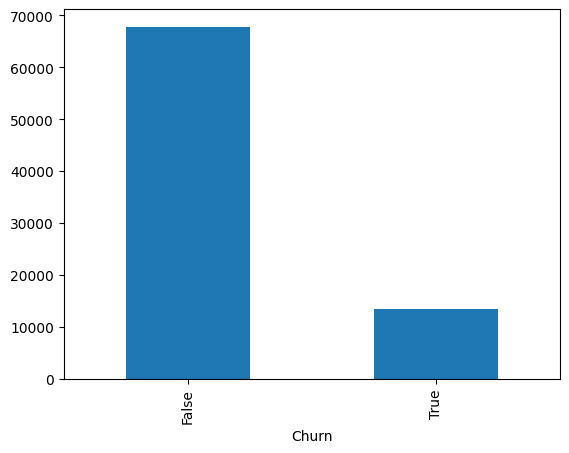

In [14]:
df_train.groupby('Churn')['Total day charge'].sum().plot(kind='bar')

<Axes: ylabel='count'>

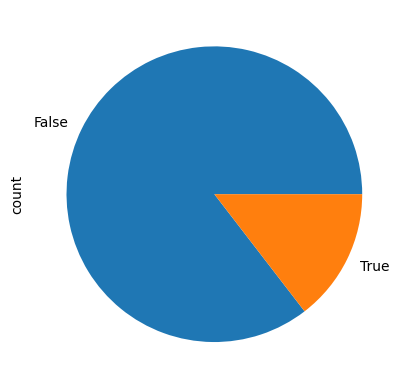

In [15]:
df_train['Churn'].value_counts().plot(kind = 'pie')

1) preprocessing of data

In [16]:
x_train = df_train.drop('Churn',axis = 1)
y_train = df_train['Churn'].map({True:1,False:0}) # change churn to be 0 and 1

In [17]:
## change object columns so  ML can read them
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x_train['State'] = le.fit_transform(x_train['State'])
x_train['International plan'] = le.fit_transform(x_train['International plan'])
x_train['Voice mail plan'] = le.fit_transform(x_train['Voice mail plan'])

In [18]:
x_train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


In [19]:
y_train.head()

,Churn
0,0
1,0
2,0
3,0
4,0


In [20]:
# Scalling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

2) perform 3 models (decsion tree, logistic regression and random forest)

In [21]:
from sklearn.tree import DecisionTreeClassifier ## for decsion tree model
Dec_tree = DecisionTreeClassifier()
Dec_tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [22]:
from sklearn.linear_model import LogisticRegression ## for logistic regression model
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [23]:
from sklearn.ensemble import RandomForestClassifier ## for random forest model
Ran_for = RandomForestClassifier()
Ran_for.fit(x_train,y_train)

RandomForestClassifier()

4. Perform hyperparameter tuning using grid search.

In [24]:
from sklearn.model_selection import GridSearchCV ## for hyperparameter tuning
# 1️ Decision Tree
dt_params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_grid.fit(x_train, y_train)
print(" best Decision Tree  :", dt_grid.best_params_)

# 2️ Logistic Regression
lr_params = {
    'C': [0.1, 1, 10],
    'max_iter': [100, 200]
}
lr_grid = GridSearchCV(LogisticRegression(), lr_params, cv=5)
lr_grid.fit(x_train, y_train)
print(" best Logistic Regression  :", lr_grid.best_params_)

# 3️ Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_grid.fit(x_train, y_train)
print(" best Random Forest  :", rf_grid.best_params_)

 best Decision Tree  : {'max_depth': 5, 'min_samples_split': 10}
 best Logistic Regression  : {'C': 0.1, 'max_iter': 100}
 best Random Forest  : {'max_depth': 10, 'n_estimators': 100}


handlinf the 20% dataset same as the 80% dataset

In [25]:
x_test = df_test.drop('Churn',axis = 1)
y_test = df_test['Churn'].map({True:1,False:0}) # change churn to be 0 and 1

In [26]:
## change object columns so  ML can read them
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x_test['State'] = le.fit_transform(x_test['State'])
x_test['International plan'] = le.fit_transform(x_test['International plan'])
x_test['Voice mail plan'] = le.fit_transform(x_test['Voice mail plan'])

In [27]:
y_test.head()

,Churn
0,0
1,1
2,1
3,0
4,0


In [28]:
# Scalling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_test = scaler.fit_transform(x_test)

3. make prediction on the 20% dataset and evaluate all the models

In [29]:
from sklearn.metrics import accuracy_score , precision_score, recall_score, f1_score ## for prediction and evaluation of the model
dt_pred = dt_grid.predict(x_test)
lr_pred = lr_grid.predict(x_test)
rf_pred = rf_grid.predict(x_test)

models = {'Decision Tress':dt_pred,
          'Logistic Regression': lr_pred,
          'Random forest': rf_pred}

for name, pred in models.items():
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, pred):.2f}")
    print(f"Precision: {precision_score(y_test, pred):.2f}")
    print(f"Recall:    {recall_score(y_test, pred):.2f}")
    print(f"F1-Score:  {f1_score(y_test, pred):.2f}")


--- Decision Tress ---
Accuracy:  0.95
Precision: 0.85
Recall:    0.77
F1-Score:  0.81
--- Logistic Regression ---
Accuracy:  0.85
Precision: 0.44
Recall:    0.18
F1-Score:  0.25
--- Random forest ---
Accuracy:  0.95
Precision: 0.98
Recall:    0.67
F1-Score:  0.80


In [30]:
results = pd.DataFrame({
    'العميل': range(len(dt_pred)),
    'التنبؤ': ['هيمشي ❌' if p == 1 else 'هيفضل ✅' for p in dt_pred],
    'الحقيقة': ['مشي ❌' if p == 1 else 'فضل ✅' for p in y_test]
})

print(results.head(10))

   العميل   التنبؤ الحقيقة
0       0  هيفضل ✅   فضل ✅
1       1  هيمشي ❌   مشي ❌
2       2  هيمشي ❌   مشي ❌
3       3  هيفضل ✅   فضل ✅
4       4  هيفضل ✅   فضل ✅
5       5  هيفضل ✅   فضل ✅
6       6  هيفضل ✅   فضل ✅
7       7  هيفضل ✅   مشي ❌
8       8  هيفضل ✅   فضل ✅
9       9  هيفضل ✅   فضل ✅
